In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [2]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

train_df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


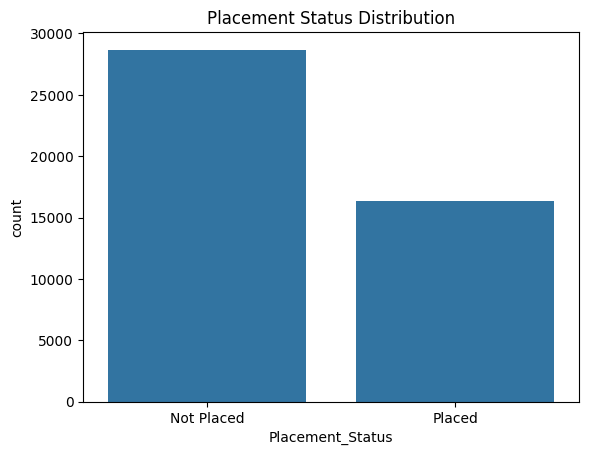

In [3]:
plt.figure()
sns.countplot(x="Placement_Status", data=train_df)
plt.title("Placement Status Distribution")
plt.show()

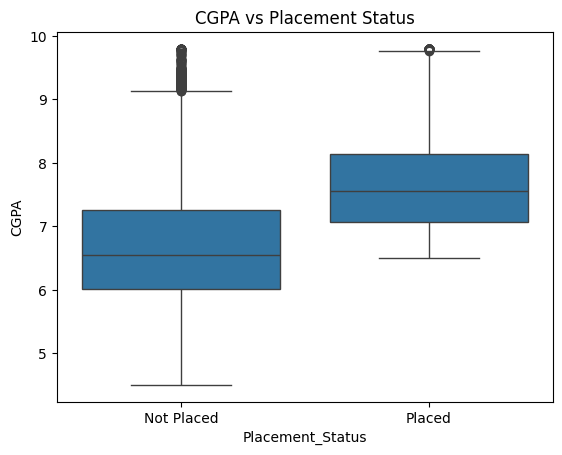

In [4]:
plt.figure()
sns.boxplot(x="Placement_Status", y="CGPA", data=train_df)
plt.title("CGPA vs Placement Status")
plt.show()

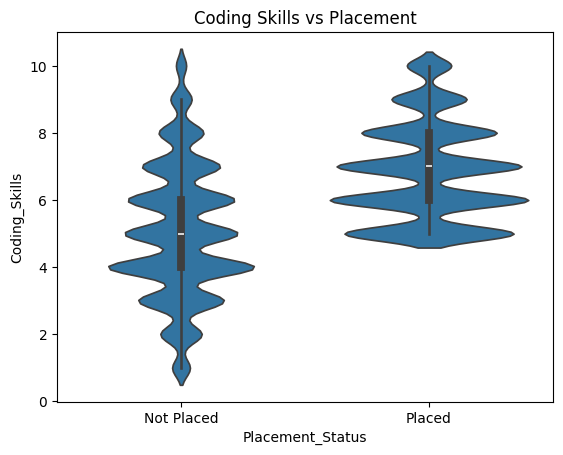

In [5]:
plt.figure()
sns.violinplot(x="Placement_Status", y="Coding_Skills", data=train_df)
plt.title("Coding Skills vs Placement")
plt.show()

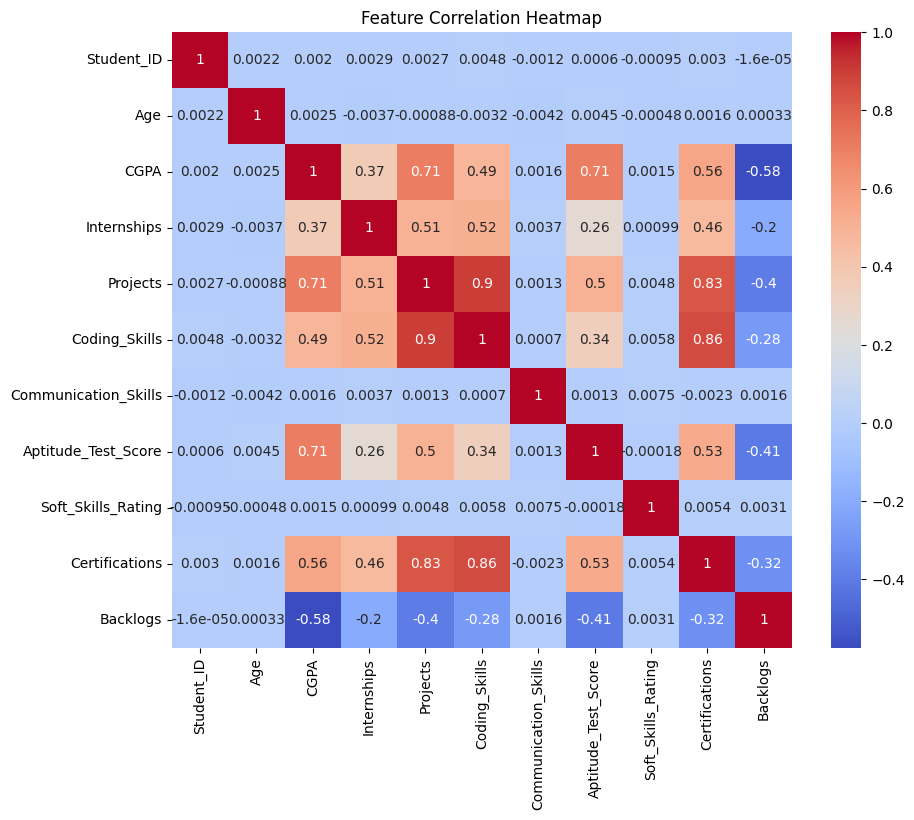

In [6]:
plt.figure(figsize=(10,8))
corr = train_df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
feature_encoders = {}

for col in ["Gender", "Degree", "Branch"]:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    feature_encoders[col] = le

In [8]:
target_encoder = LabelEncoder()
train_df["Placement_Status"] = target_encoder.fit_transform(train_df["Placement_Status"])
test_df["Placement_Status"] = target_encoder.transform(test_df["Placement_Status"])

In [9]:
X_train = train_df.drop("Placement_Status", axis=1)
y_train = train_df["Placement_Status"]

X_test = test_df.drop("Placement_Status", axis=1)
y_test = test_df["Placement_Status"]

In [10]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, n_estimators=300, random_state=42)

In [11]:
y_pred = rf.predict(X_test)

print("Accucy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accucy: 0.9998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3188
           1       1.00      1.00      1.00      1812

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



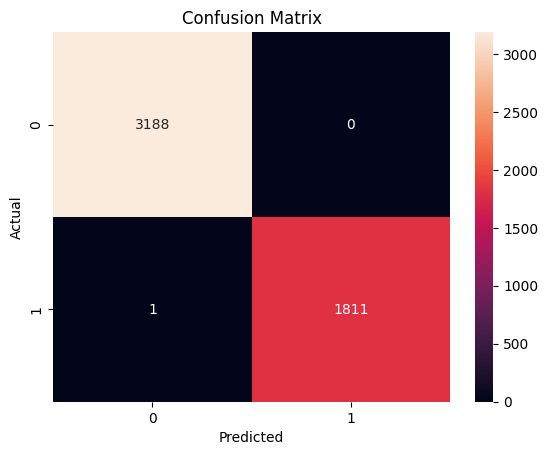

In [12]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

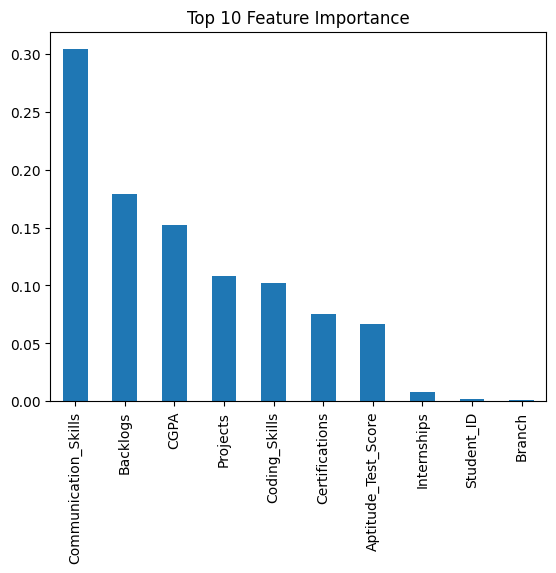

In [13]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Feature Importance")
plt.show()

In [14]:
new_student = pd.DataFrame([{
    "Student_ID": 99999,
    "Age": 22,
    "Gender": feature_encoders["Gender"].transform(["Male"])[0],
    "Degree": feature_encoders["Degree"].transform(["B.Tech"])[0],
    "Branch": feature_encoders["Branch"].transform(["CSE"])[0],
    "CGPA": 8.5,
    "Internships": 2,
    "Projects": 4,
    "Coding_Skills": 8,
    "Communication_Skills": 7,
    "Aptitude_Test_Score": 80,
    "Soft_Skills_Rating": 7,
    "Certifications": 2,
    "Backlogs": 0
}])

pred = rf.predict(new_student)
print("Placement Prediction:", target_encoder.inverse_transform(pred)[0])

Placement Prediction: Placed


logistic regeression model

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [16]:
lr = LogisticRegression(max_iter=1000, random_state=42)

In [17]:
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [18]:
y_pred_lr = lr.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9998
Precision: 1.0
Recall: 0.9994481236203091
F1 Score: 0.9997239856472536

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3188
           1       1.00      1.00      1.00      1812

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



extras
